This file processes a text file collected with NRG's Modbus Data Client (MDC) connected to the ProtoNode, which is configured identically for all NextEra projects. It performs a variety of checks, which are summarized, and plots all of the signals for visual inspection. Solar angles are checked against calculated values.

In [5]:
import pandas as pd

from se_analysis import protonode, project
from se_analysis import validation as v
from se_analysis.plot import plot_signals


A `SPEC` specifies the expected signal ranges for a file. Any spec can be over-ridden for a site that legitimately differs.

In [3]:
# The standard ProtoNode expectations. For a site that legitimately differs:
#     spec = protonode.SPEC.override(ranges={"Logger_Voltage": (23, 26)})
spec = protonode.SPEC

Modify this cell to point to the correct ProtoNode file path.

In [7]:
file_path = project("SRM", "Ninnescah-Flats_KS", "MET1", "MDC_TCP_172_19_3_123_MET1_ProtoNode 2026-08-21_14_34_26.txt")
df = protonode.read(file_path)
df

,ProtoNode.Start_Address,ProtoNode.Register_Count,ProtoNode.Register_Type,ProtoNode.Modbus_Poll_Duration,Counter,stationname,Logger_SN,Unnamed: 8,Logger_Voltage,MetSENS500_SN,...,reserved,reserved.1,reserved.2,reserved.3,reserved.4,reserved.5,reserved.6,reserved.7,reserved.8,reserved.9
ProtoNode.Modbus_Poll_Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-08-21 14:34:26.666,0,124,Holding,3,76,-15712,2887,-99,24.013271,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
2026-08-21 14:34:27.665,0,124,Holding,2,77,-15712,2887,-99,24.013271,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
2026-08-21 14:34:28.664,0,124,Holding,5,78,-15712,2887,-99,24.013271,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
2026-08-21 14:34:29.659,0,124,Holding,3,79,-15712,2887,-99,24.013271,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
2026-08-21 14:34:30.661,0,124,Holding,6,80,-15712,2887,-99,24.013271,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-21 14:43:20.664,0,124,Holding,22,4,-15712,2887,-99,24.013658,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
2026-08-21 14:43:21.658,0,124,Holding,25,5,-15712,2887,-99,24.013658,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99
2026-08-21 14:43:22.661,0,124,Holding,25,6,-15712,2887,-99,24.013658,-99,...,-99,-99,-99,-99,-99,-99,-99,-99,-99,-99


Remove unused columns.

In [8]:
cols = protonode.signal_columns(df)
len(cols)

72

Run every check in the spec. `summarize` lists every signal the spec tests, the passing ones included; `findings` holds only the problems.

In [9]:
findings = v.validate(df, spec)
v.summarize(findings, spec)

,check,signal,n_findings,pass
0,equivalent,stationname vs Logger_SN,1,False
1,range,POA_ClassA_Pressure,1,False
2,stall,GHI_ClassA_Pressure,6,False
3,stall,GHI_Tilt_ClassA,1,False
4,stall,POA_ClassA,1,False
...,...,...,...,...
87,stall,RefCell_1,0,True
88,stall,RefCell_Down,0,True
89,stall,RefCell_Down_Temp,0,True
90,stall,Soiling_Isc_Ratio,0,True


All findings, from every check.

In [10]:
findings

,check,signal,detail,value,start,end,duration,n_samples
0,range,POA_ClassA_Pressure,"outside [800, 1200]",0,2026-08-21 14:34:26.666000,2026-08-21 14:43:24.666000,0 days 00:08:58,539
1,equivalent,stationname vs Logger_SN,539 of 539 rows differ,-15712,2026-08-21 14:34:26.666000,2026-08-21 14:43:24.666000,0 days 00:08:58,539
2,stall,GHI_ClassA_Pressure,held 1070.46875 for 0 days 00:00:26,1070.46875,2026-08-21 14:35:01.666000,2026-08-21 14:35:27.666000,0 days 00:00:26,26
3,stall,GHI_ClassA_Pressure,held 1070.96875 for 0 days 00:00:21.002000,1070.96875,2026-08-21 14:37:08.663000,2026-08-21 14:37:29.665000,0 days 00:00:21.002000,21
4,stall,GHI_ClassA_Pressure,held 1070.84375 for 0 days 00:00:20.009000,1070.84375,2026-08-21 14:37:59.657000,2026-08-21 14:38:19.666000,0 days 00:00:20.009000,20
5,stall,GHI_ClassA_Pressure,held 1070.90625 for 0 days 00:00:27.995000,1070.90625,2026-08-21 14:38:33.666000,2026-08-21 14:39:01.661000,0 days 00:00:27.995000,28
6,stall,GHI_ClassA_Pressure,held 1070.84375 for 0 days 00:00:25.993000,1070.84375,2026-08-21 14:39:15.666000,2026-08-21 14:39:41.659000,0 days 00:00:25.993000,26
7,stall,GHI_ClassA_Pressure,held 1070.9375 for 0 days 00:00:48.988000,1070.9375,2026-08-21 14:40:04.666000,2026-08-21 14:40:53.654000,0 days 00:00:48.988000,49
8,stall,POA_ClassA_Pressure,held 0 for 0 days 00:08:58,0.0,2026-08-21 14:34:26.666000,2026-08-21 14:43:24.666000,0 days 00:08:58,539
9,stall,GHI_Tilt_ClassA,held 0.269999981 for 0 days 00:00:26.008000,0.27,2026-08-21 14:41:20.656000,2026-08-21 14:41:46.664000,0 days 00:00:26.008000,26


Plot each signal to visually inspect.

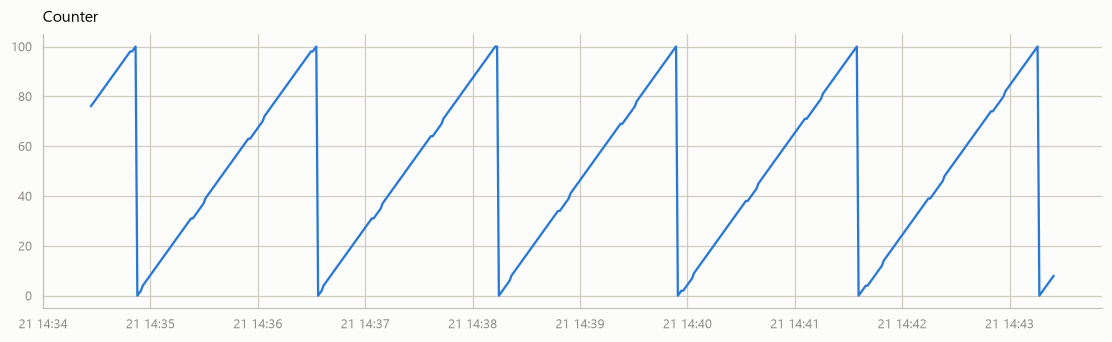

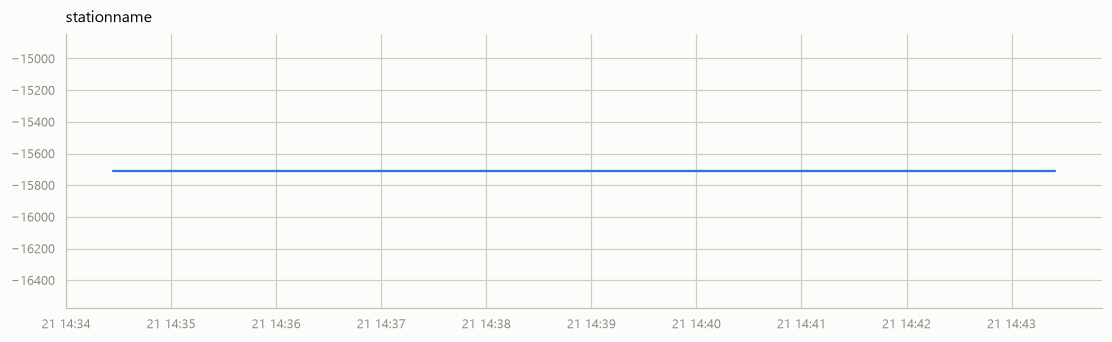

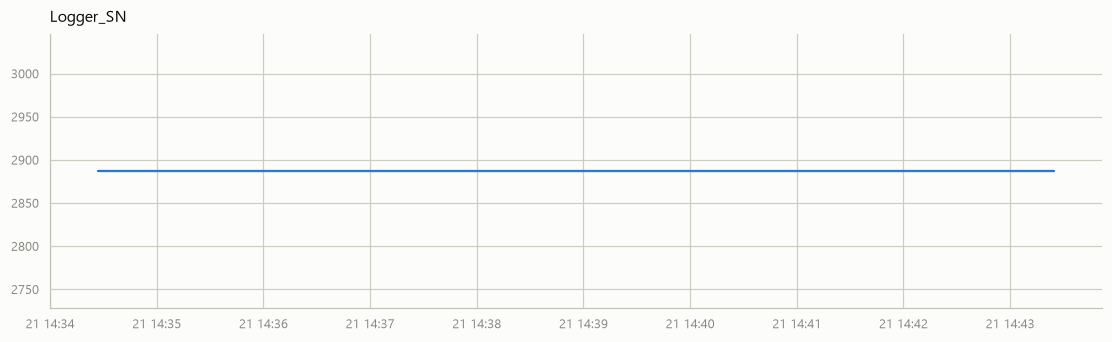

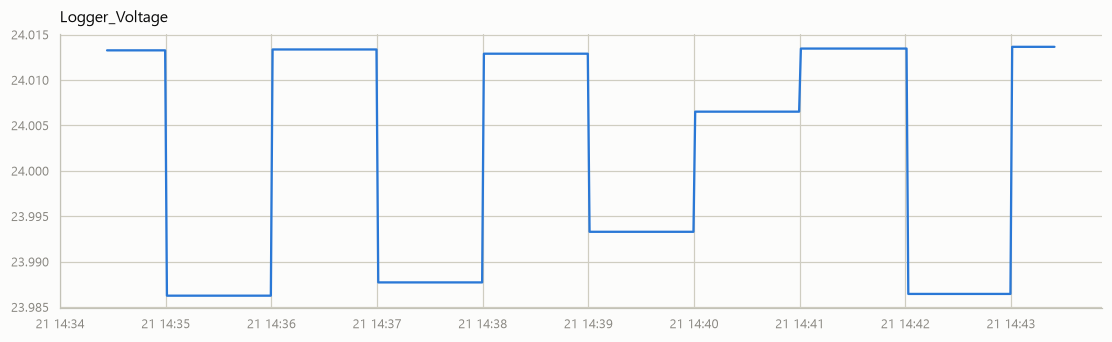

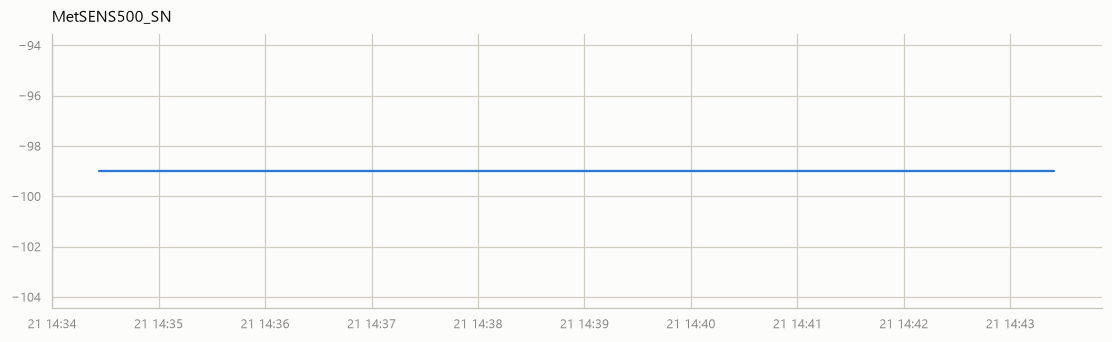

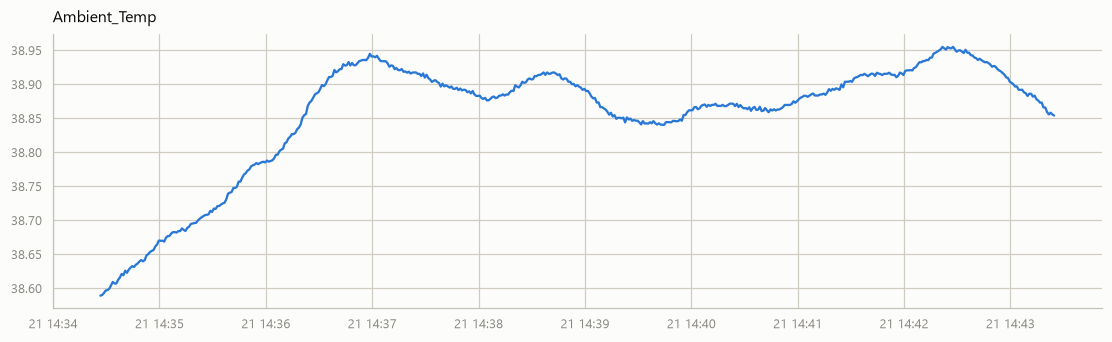

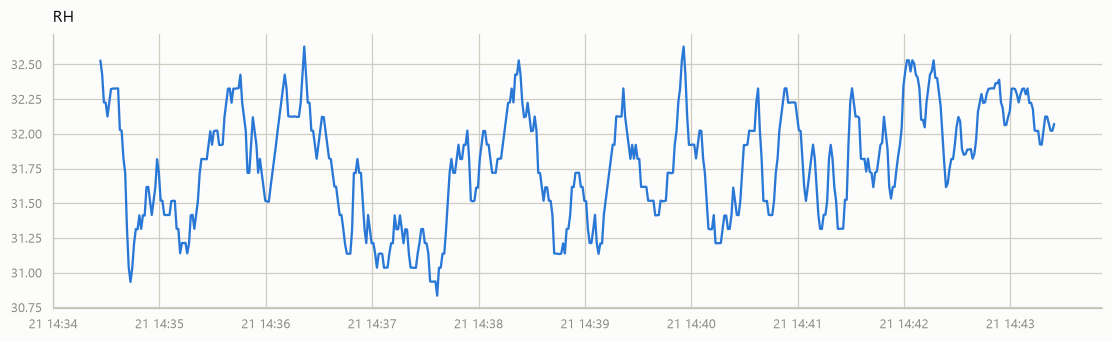

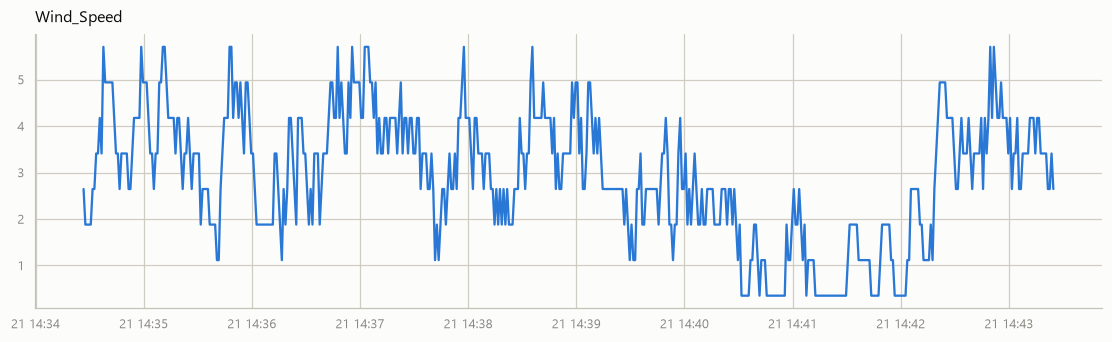

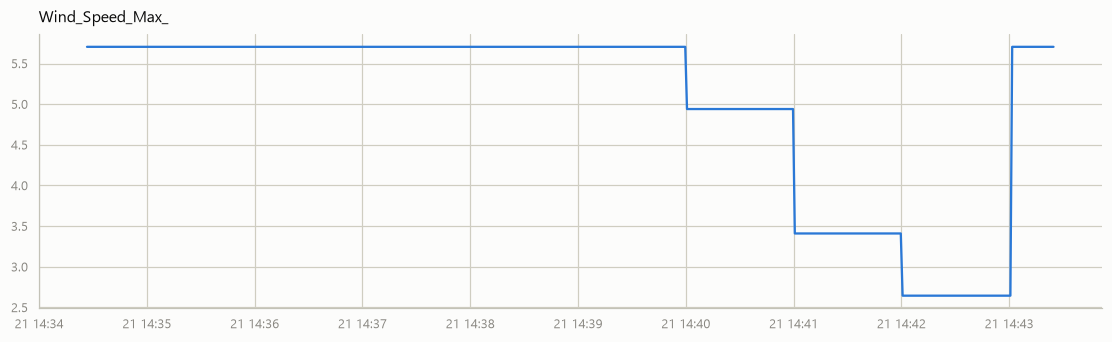

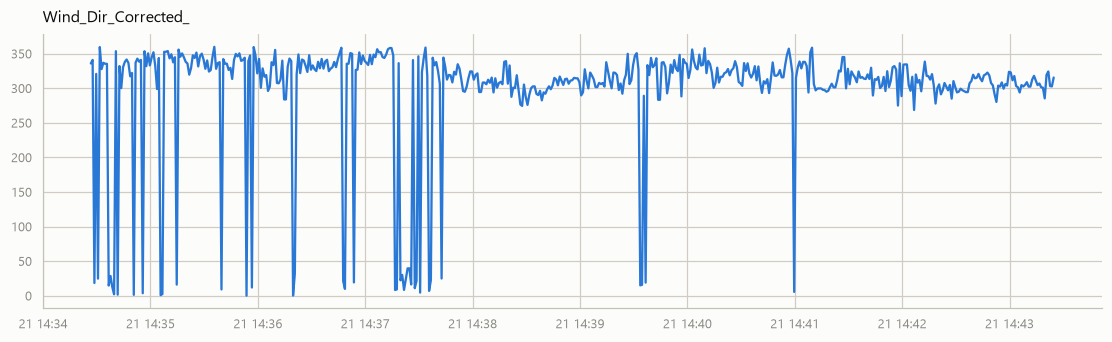

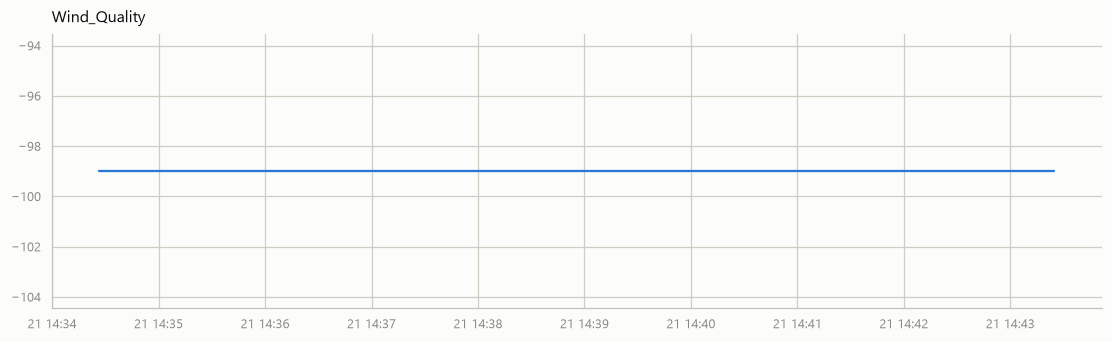

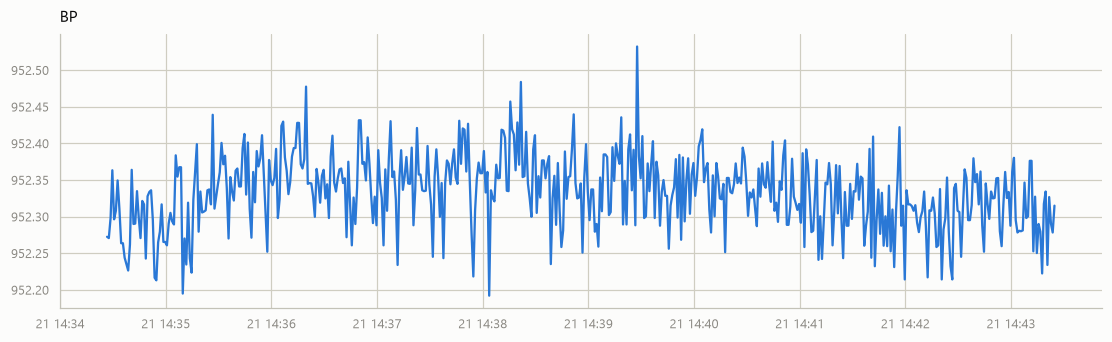

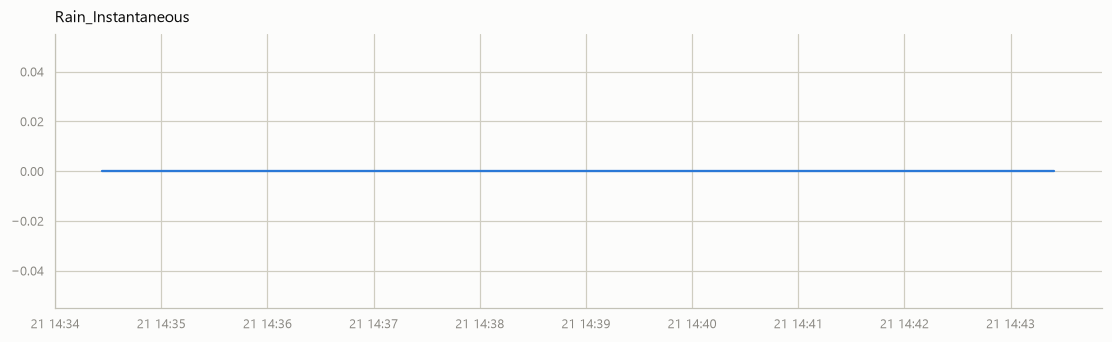

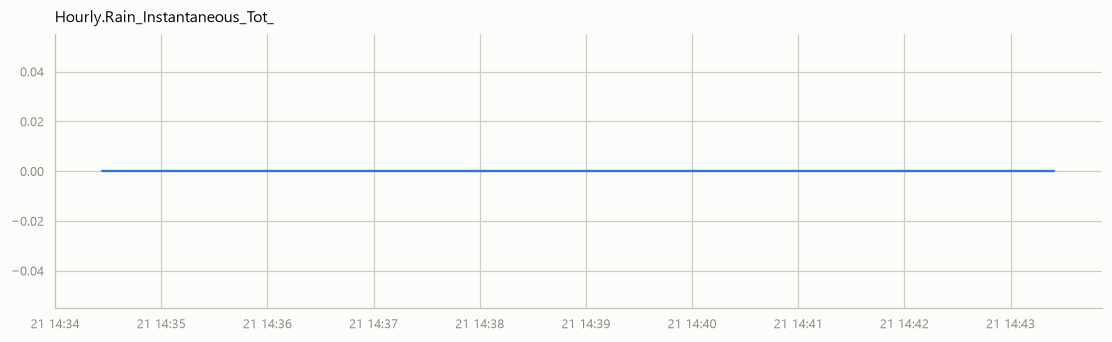

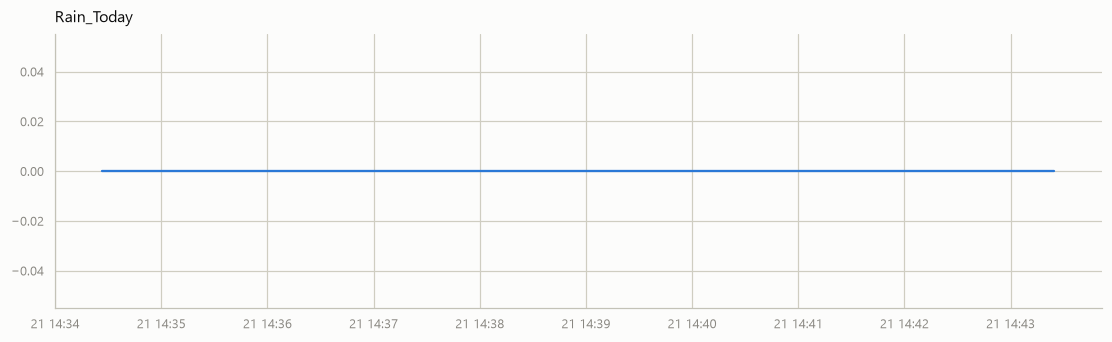

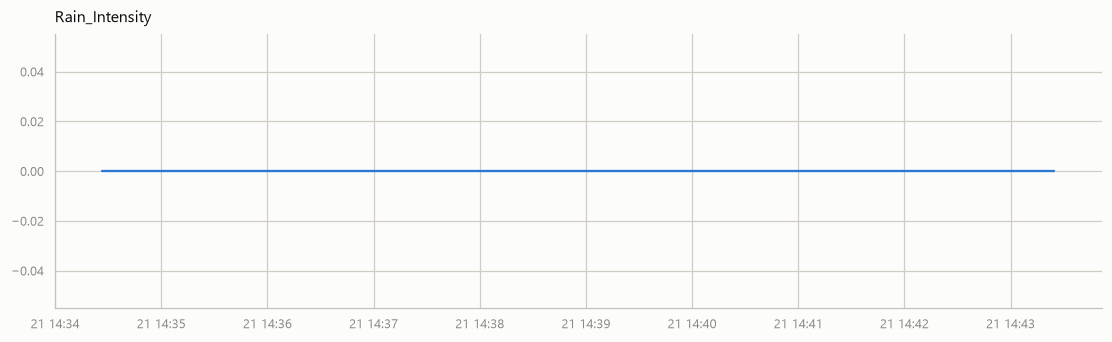

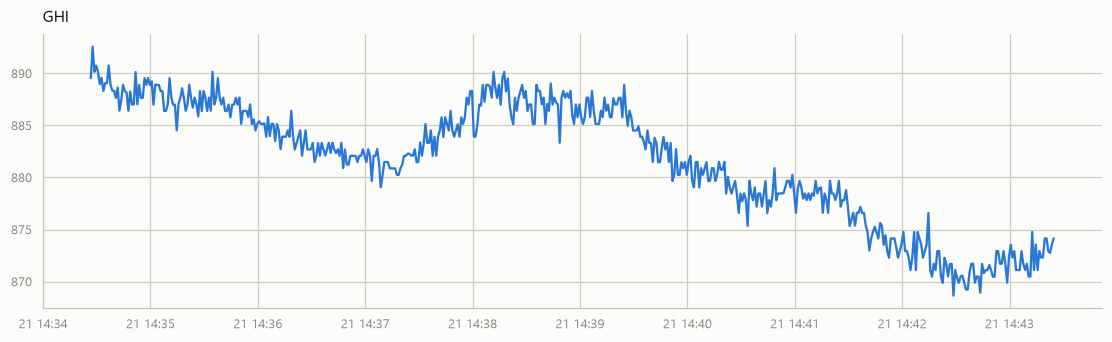

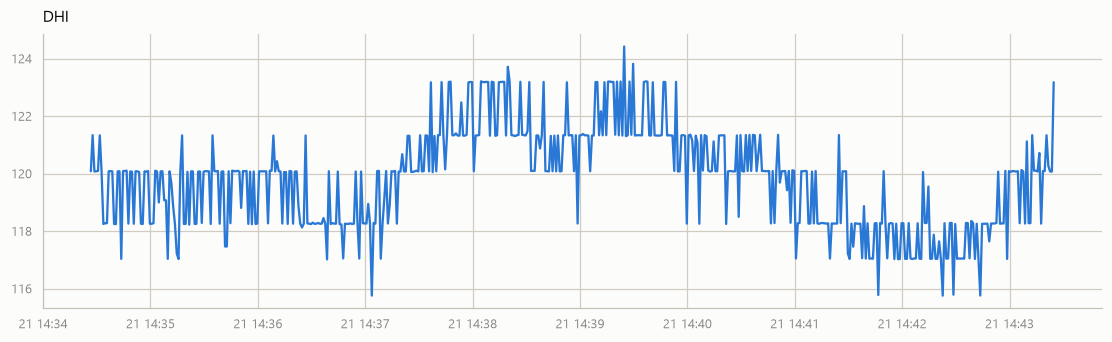

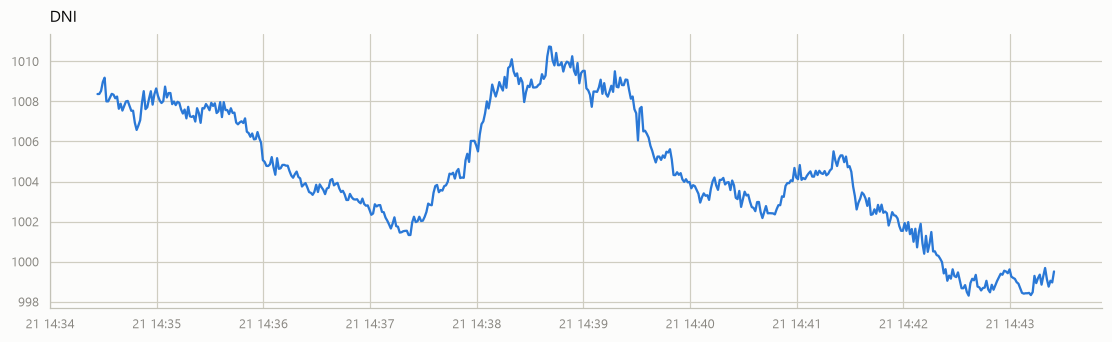

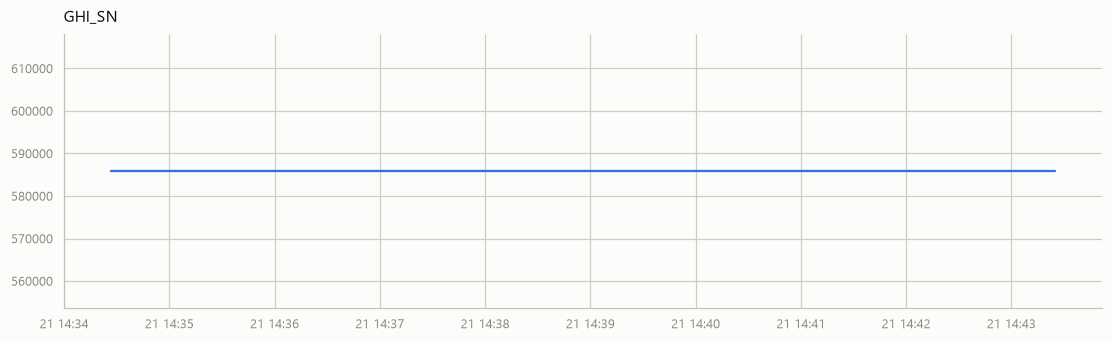

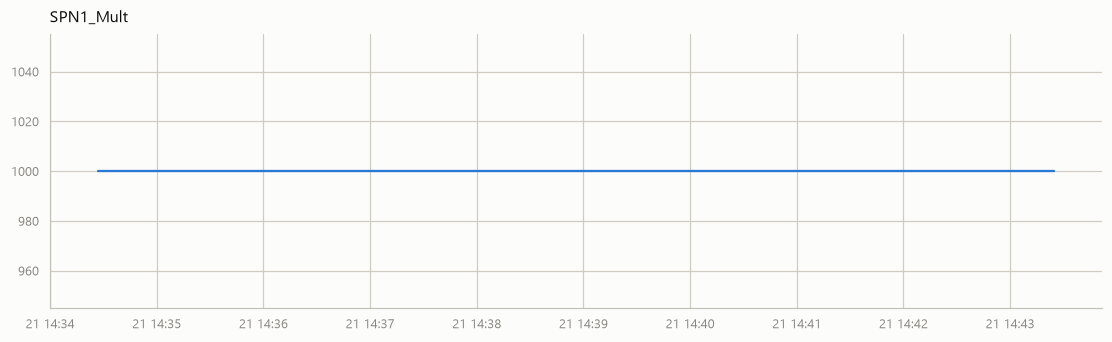

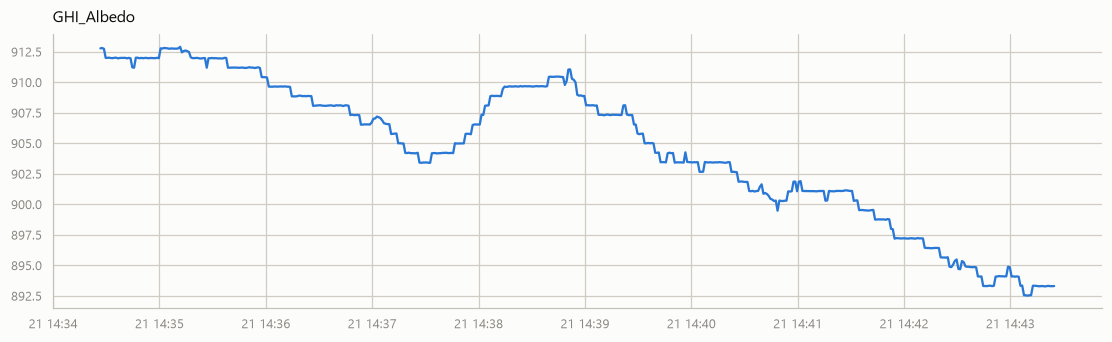

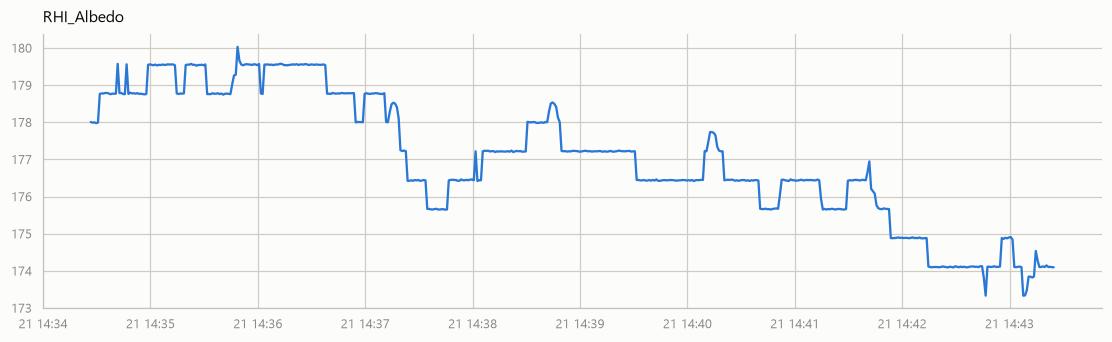

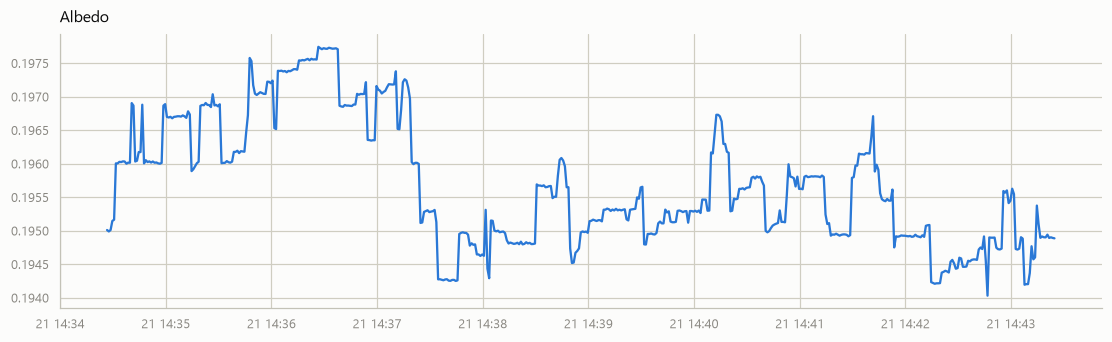

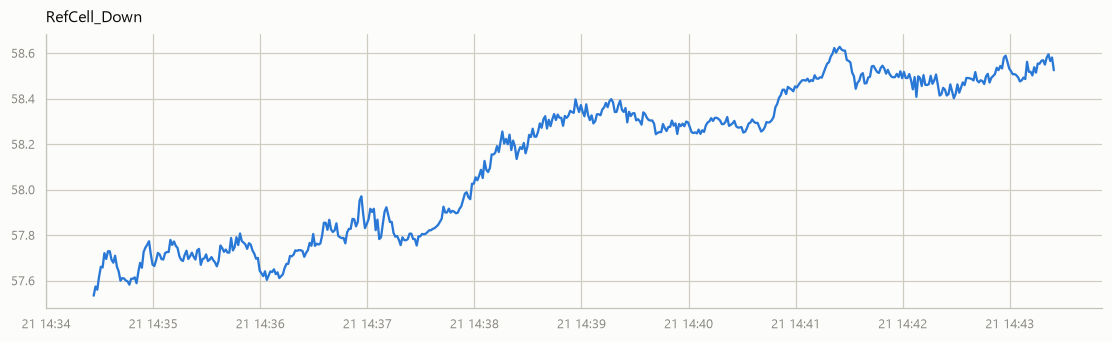

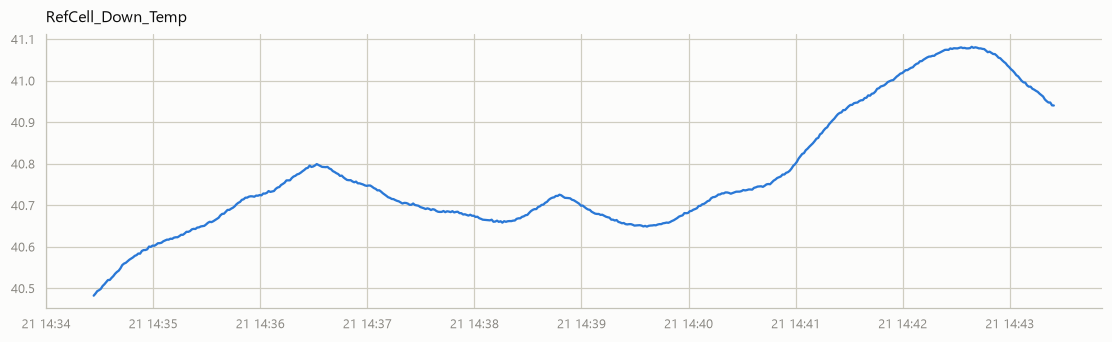

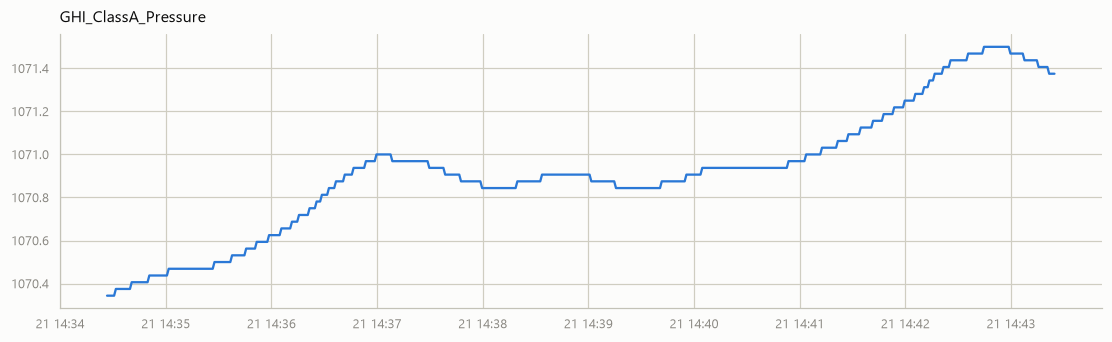

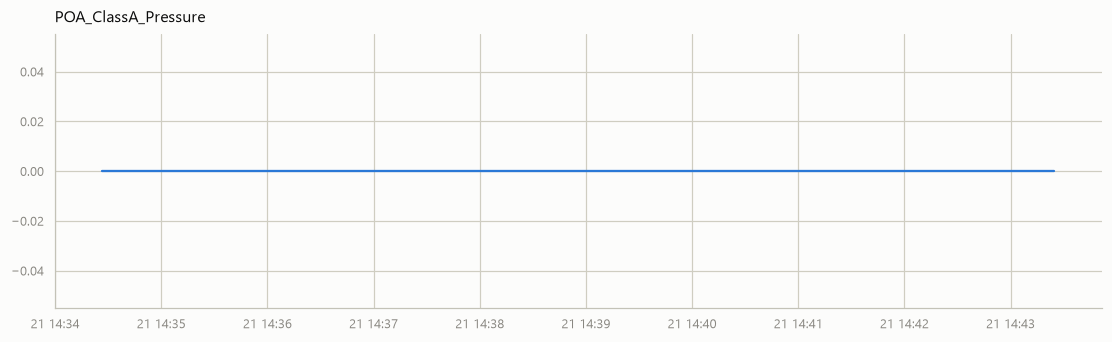

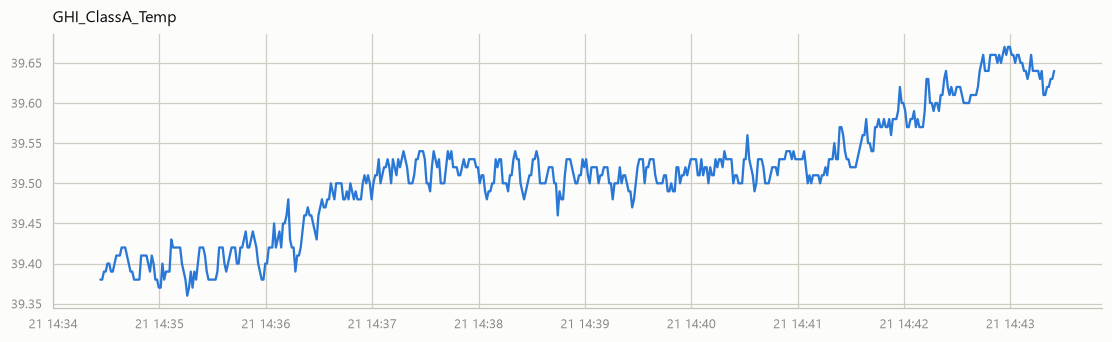

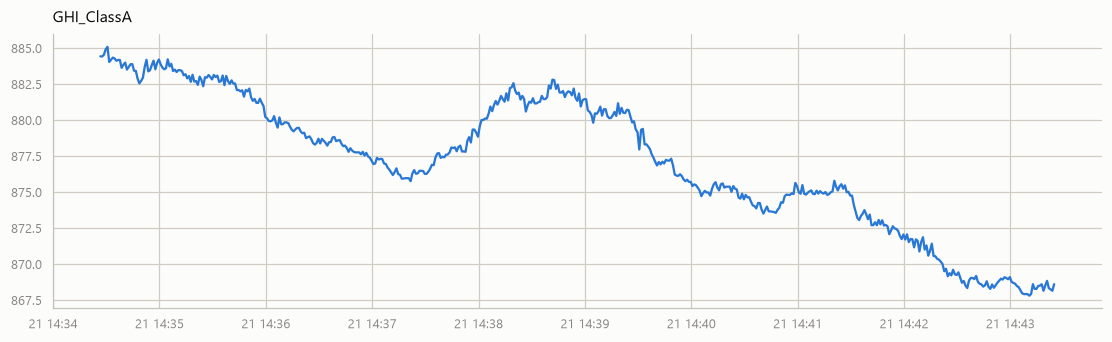

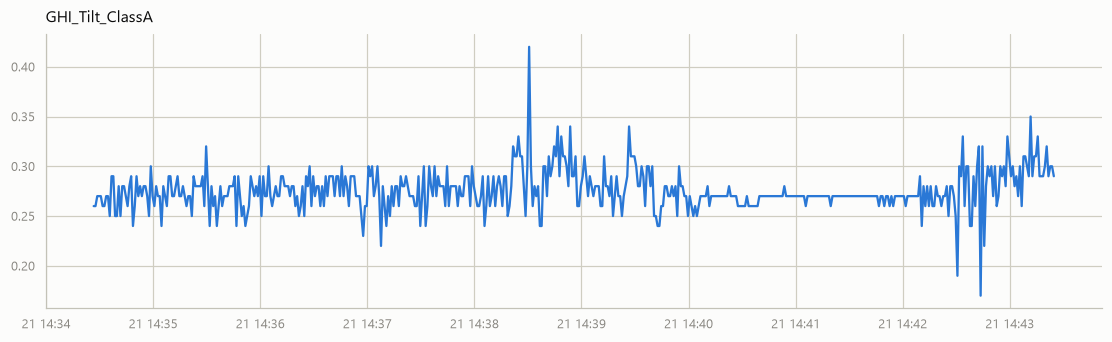

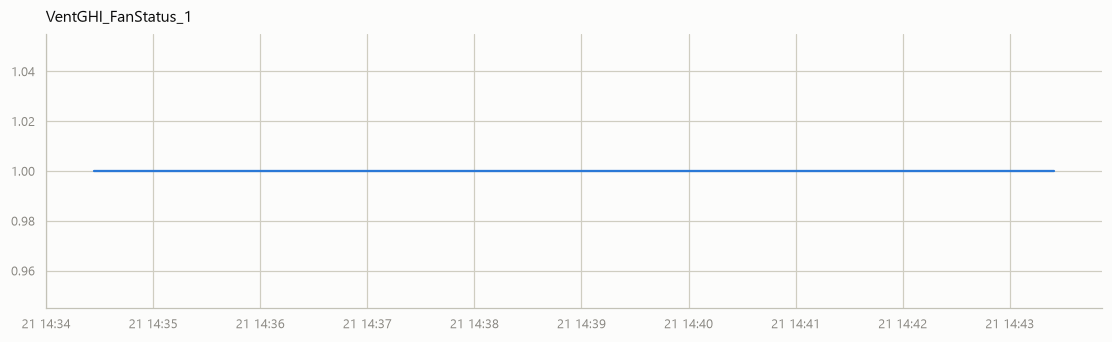

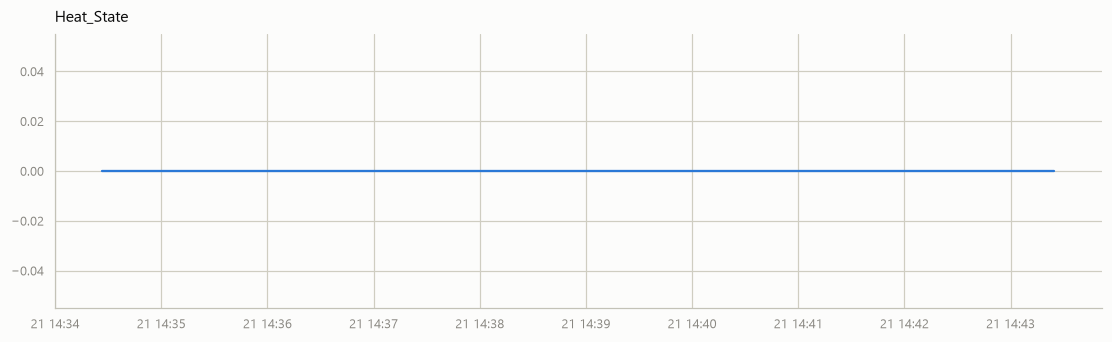

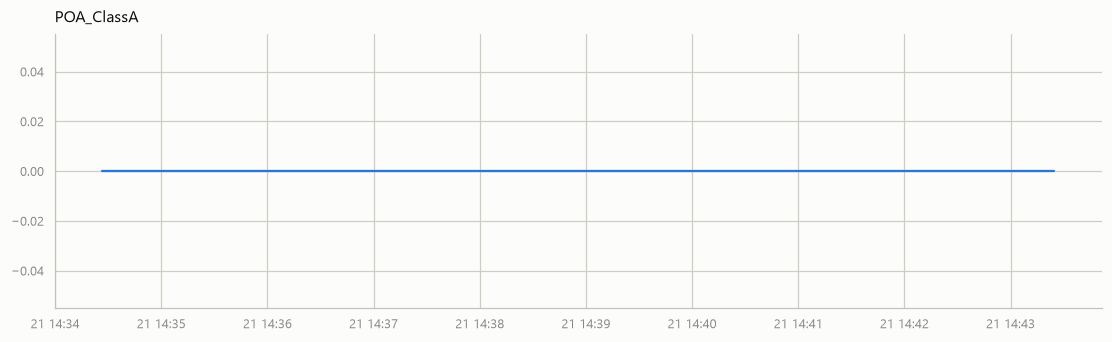

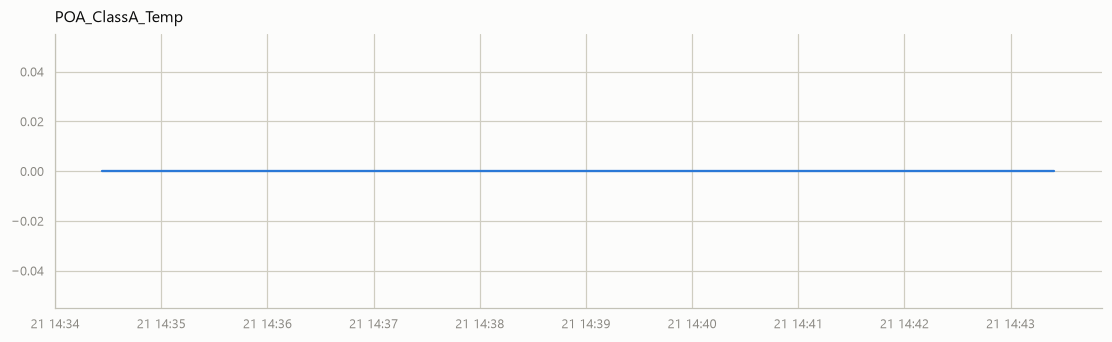

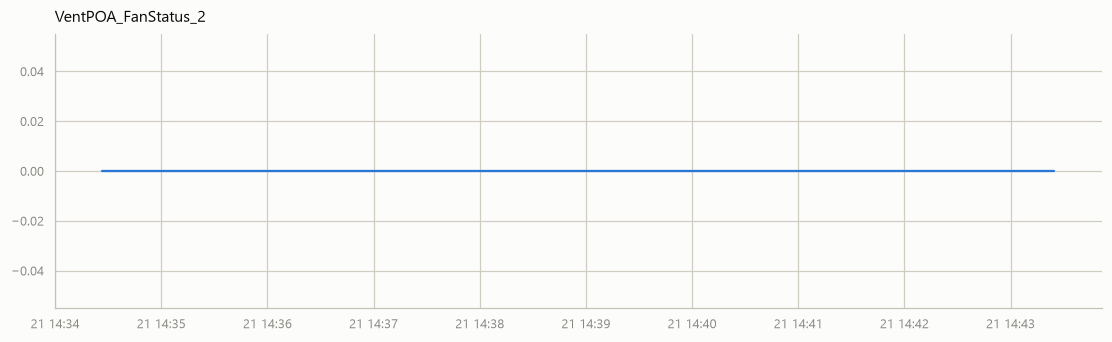

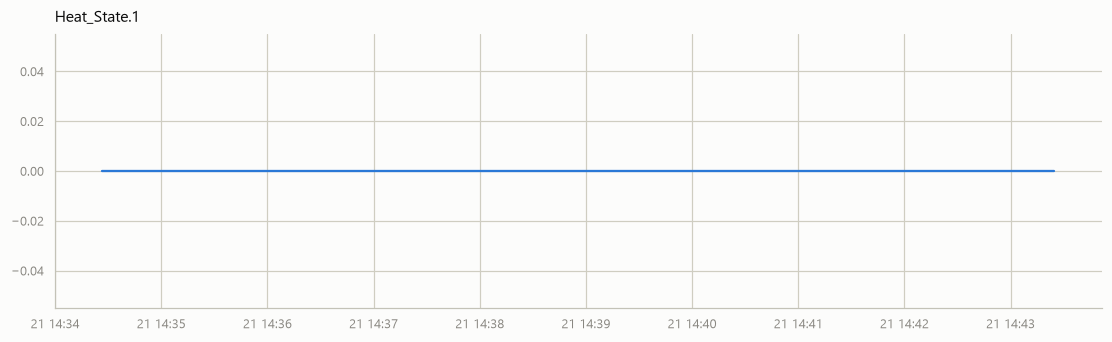

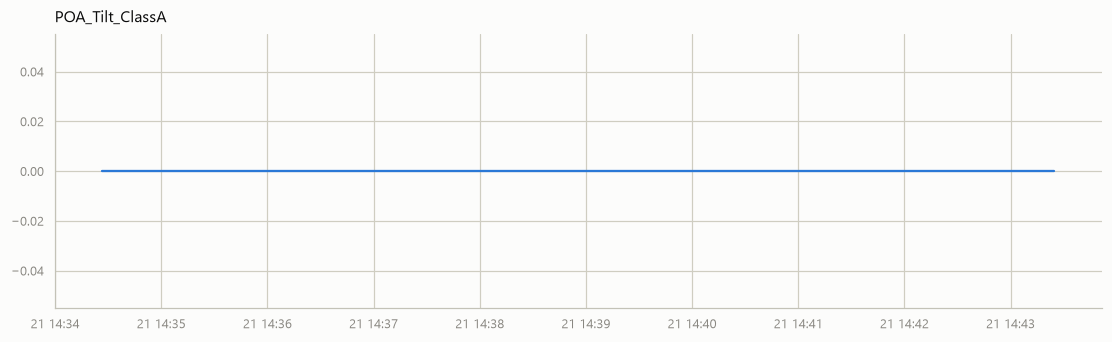

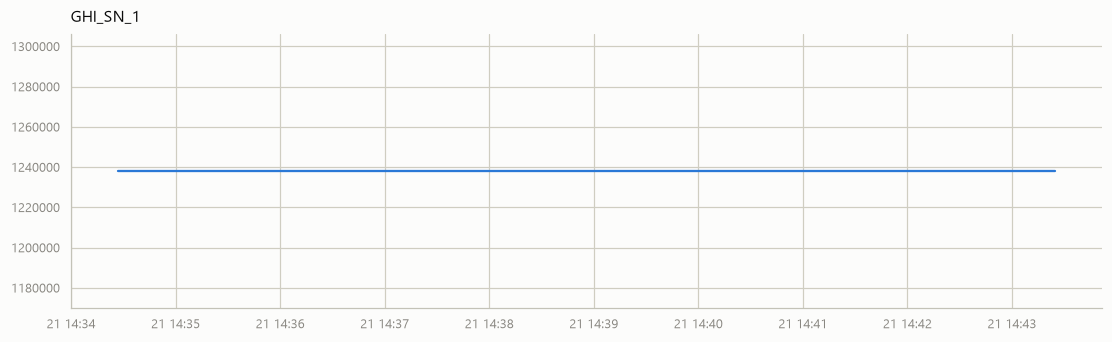

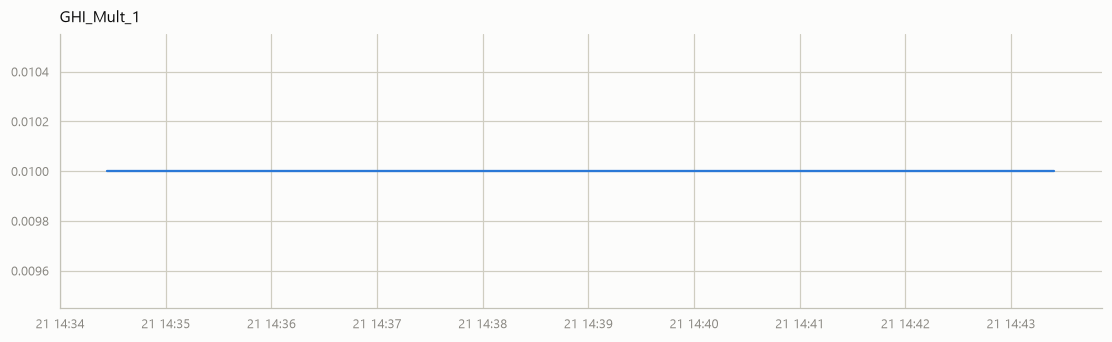

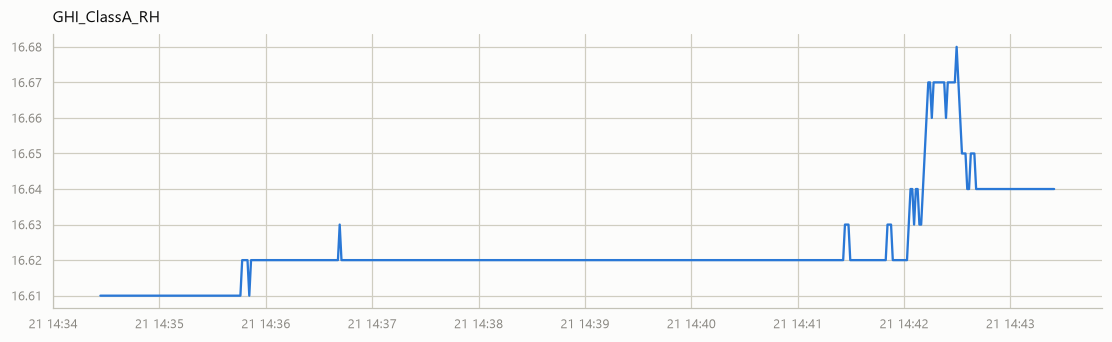

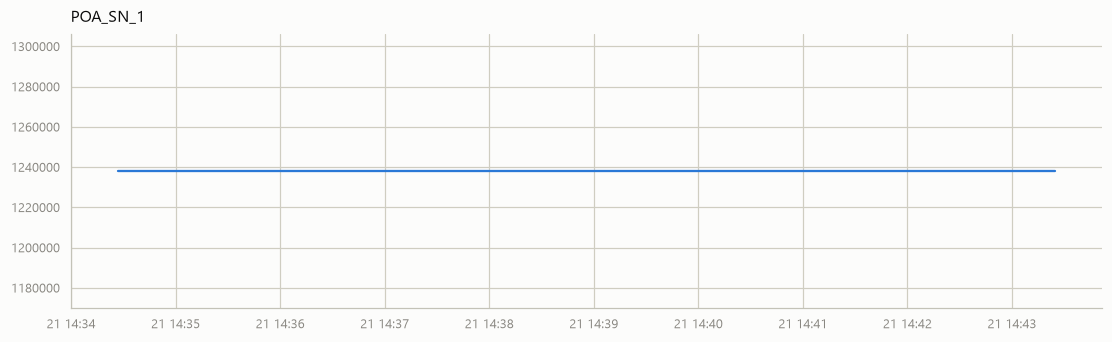

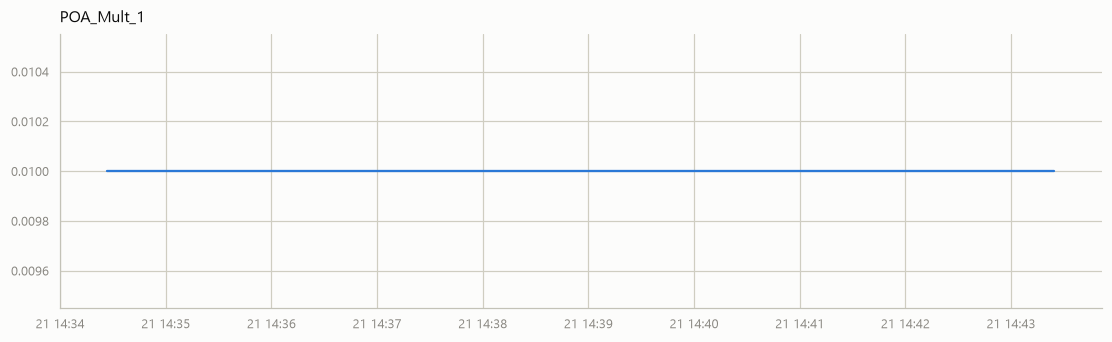

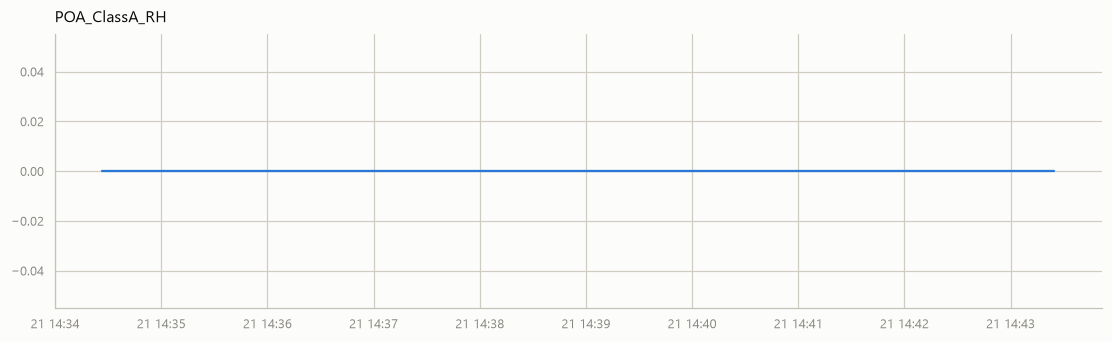

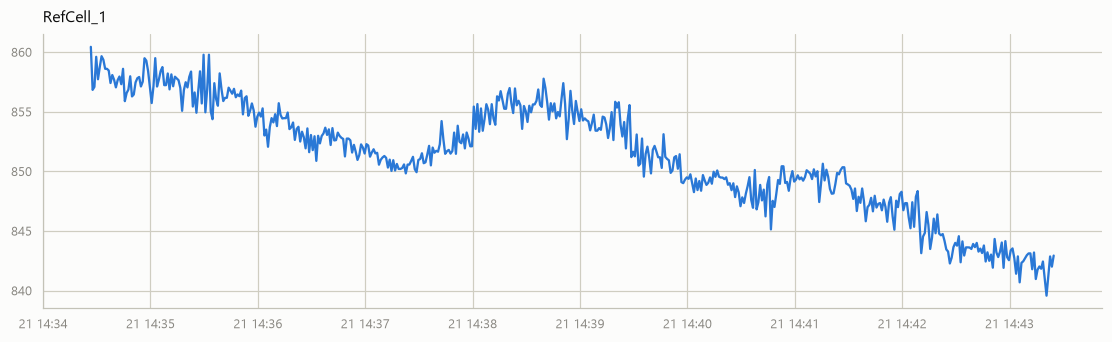

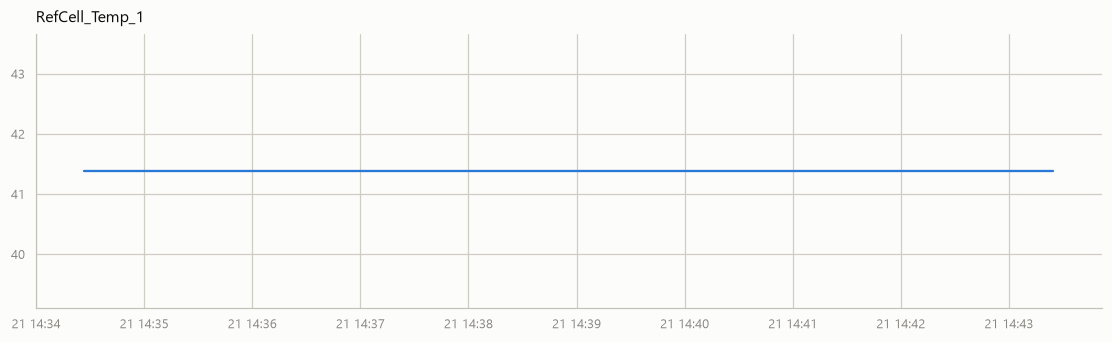

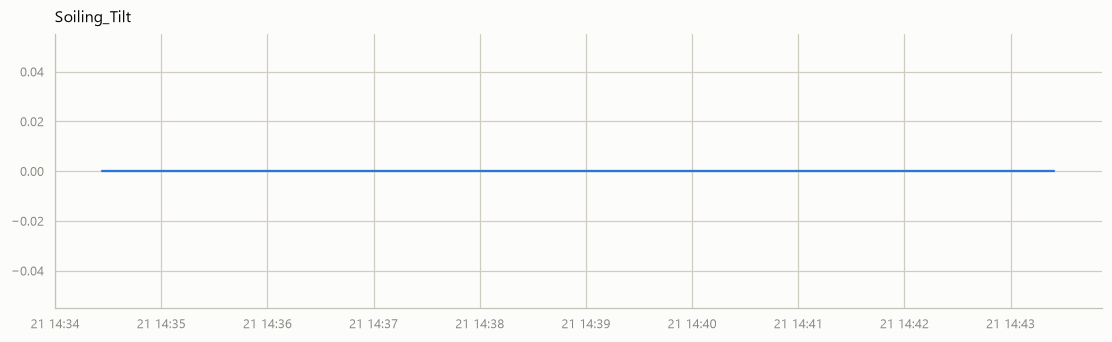

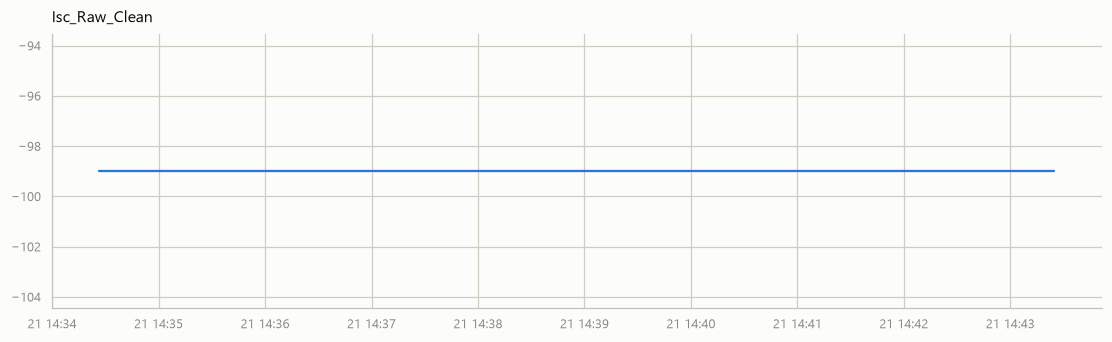

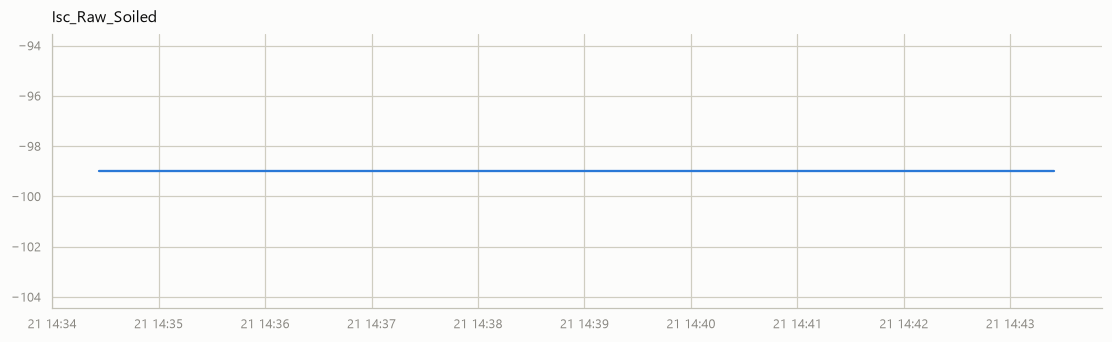

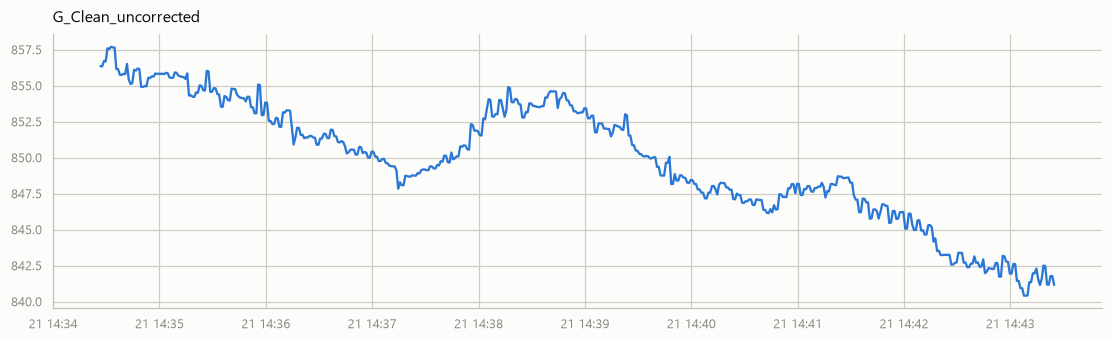

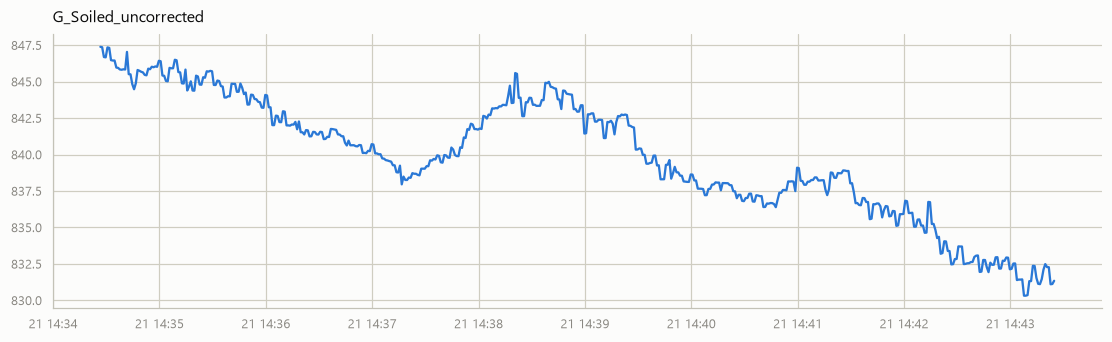

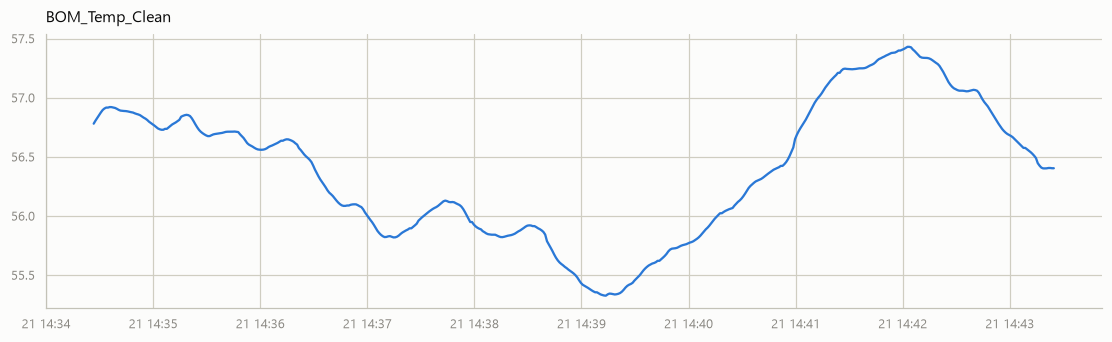

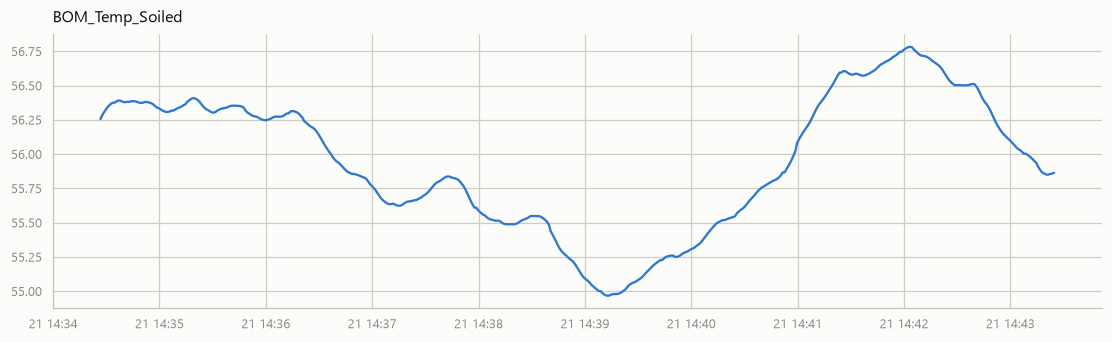

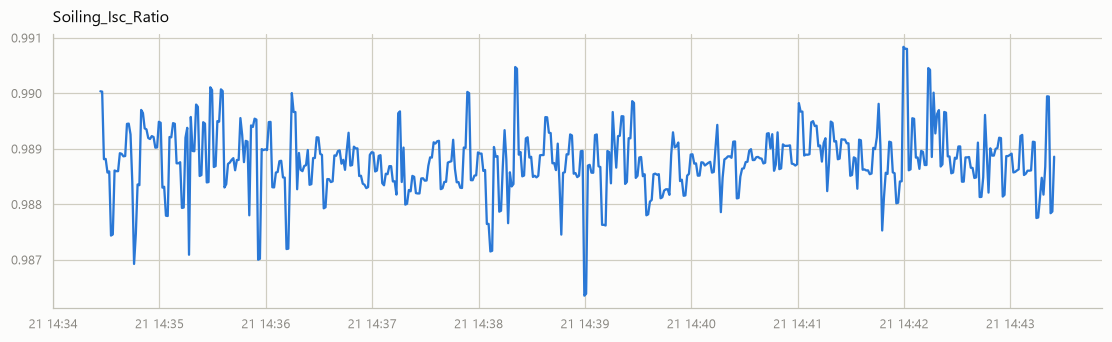

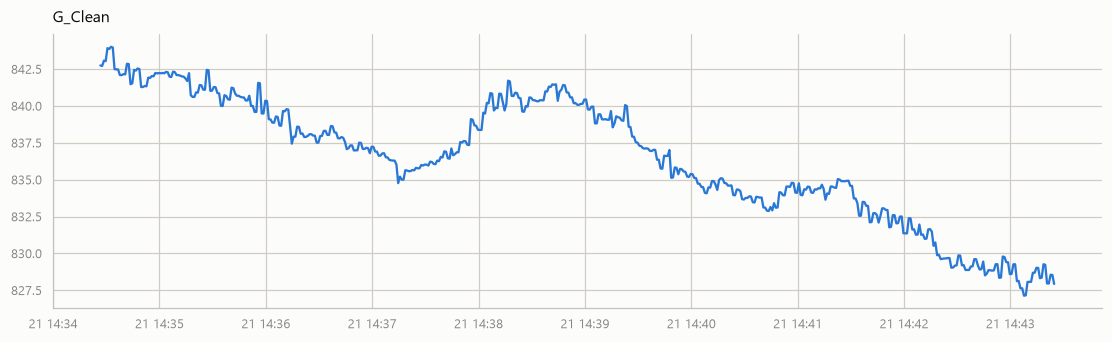

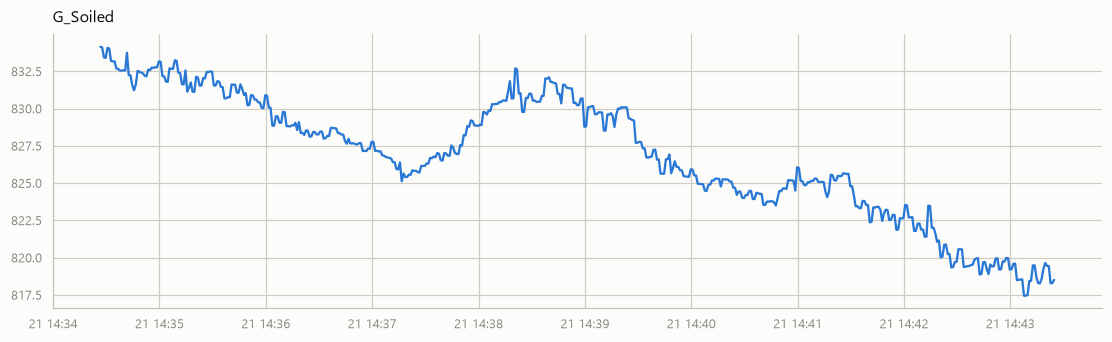

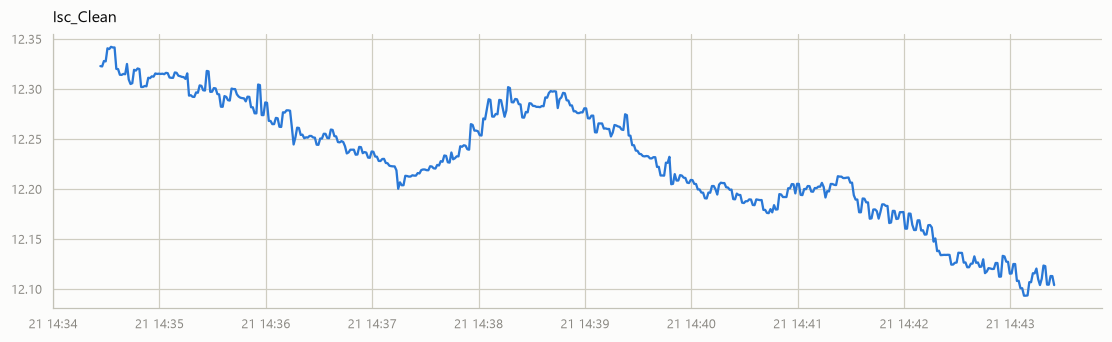

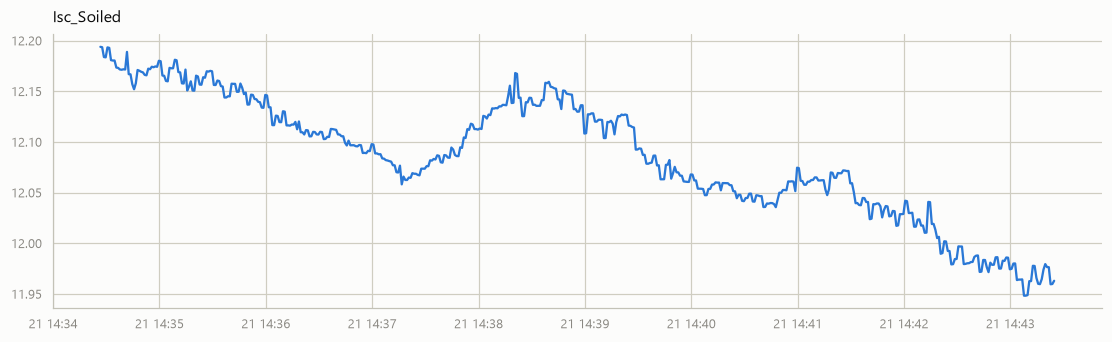

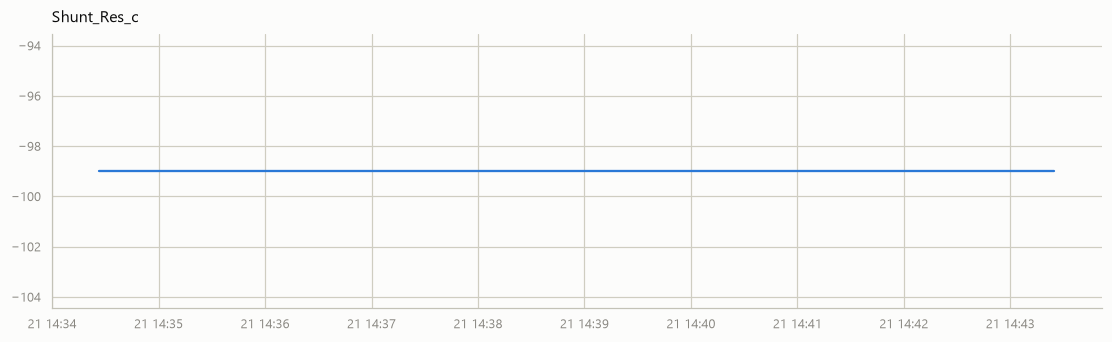

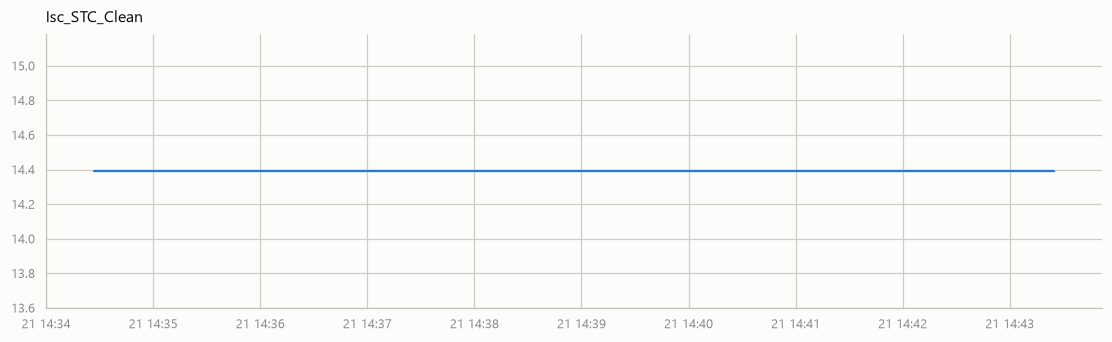

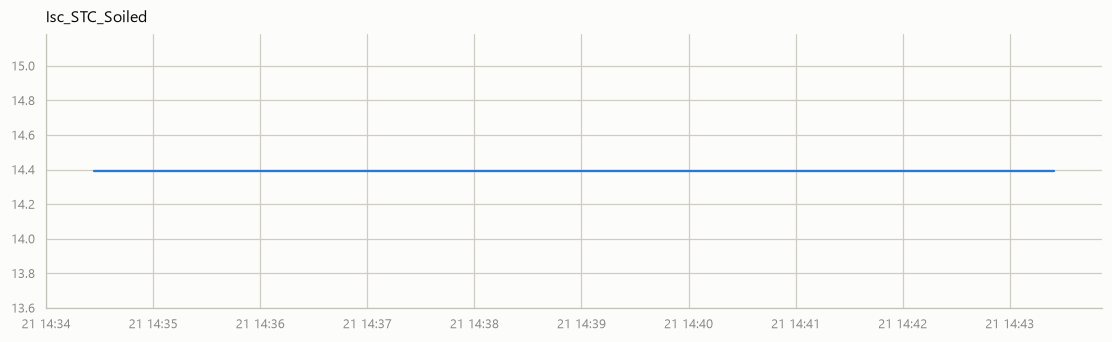

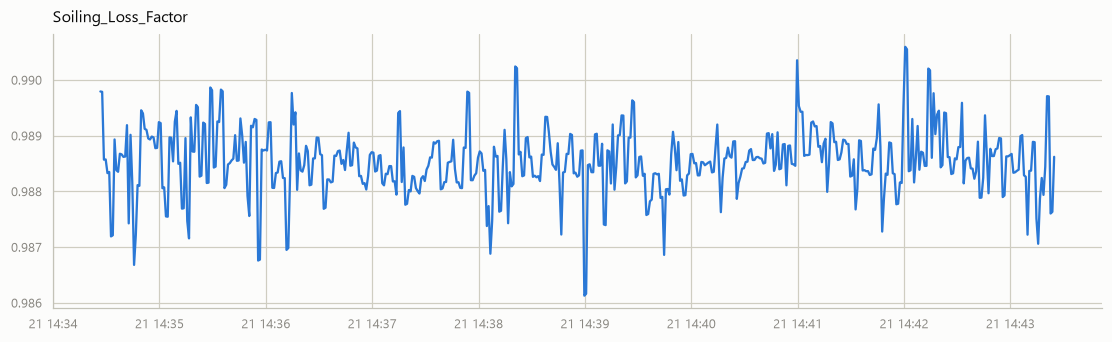

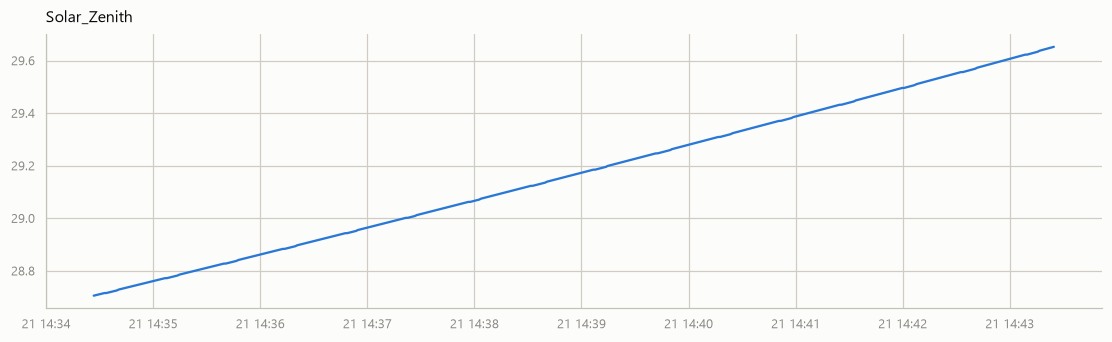

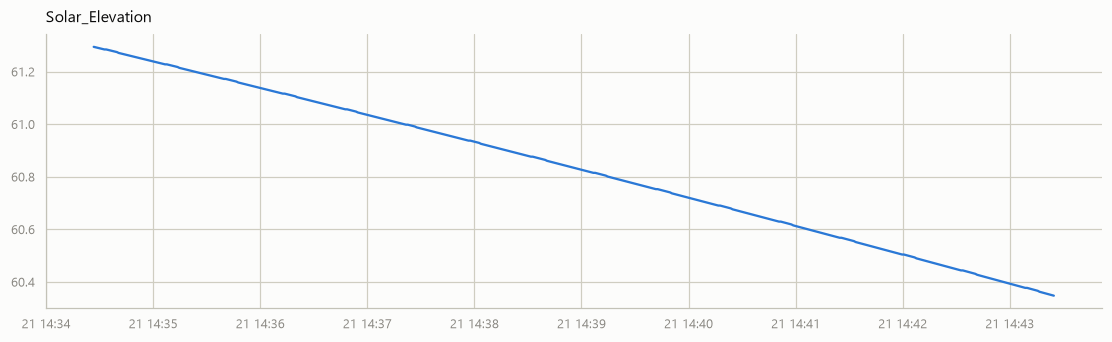

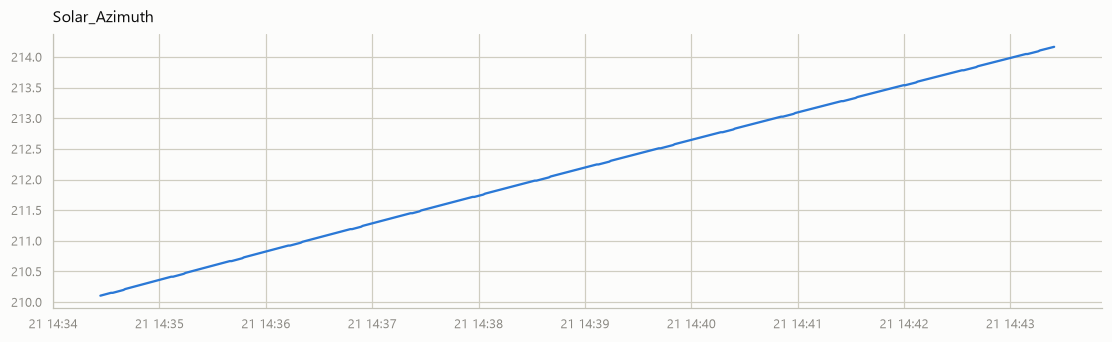

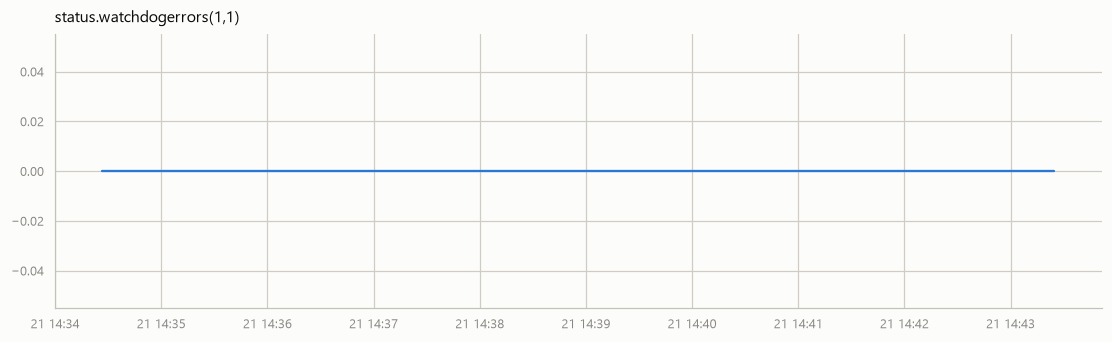

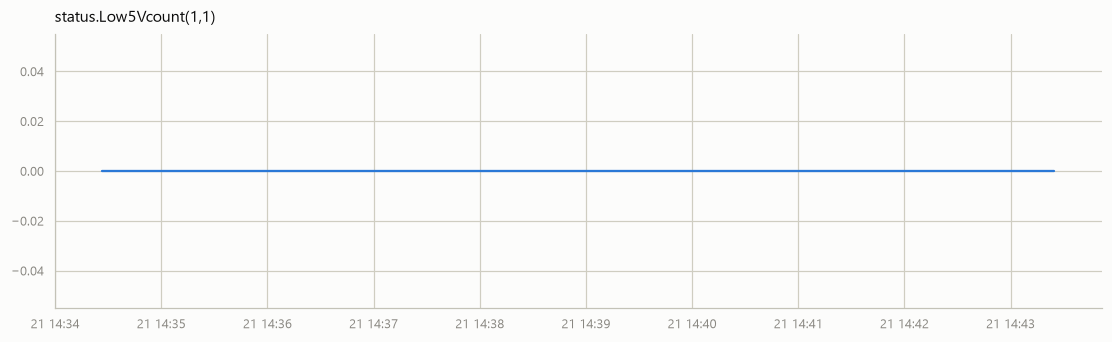

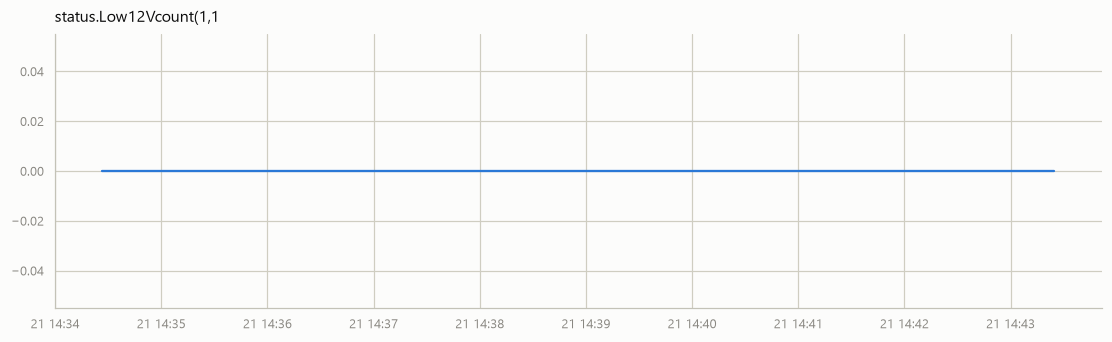

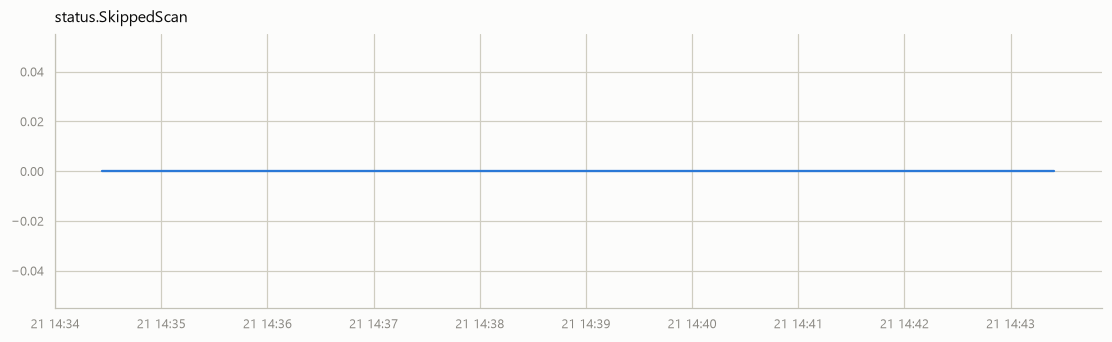

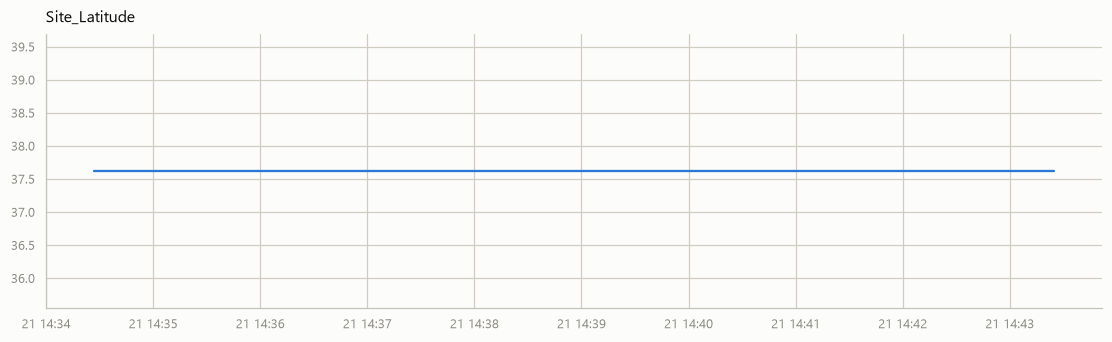

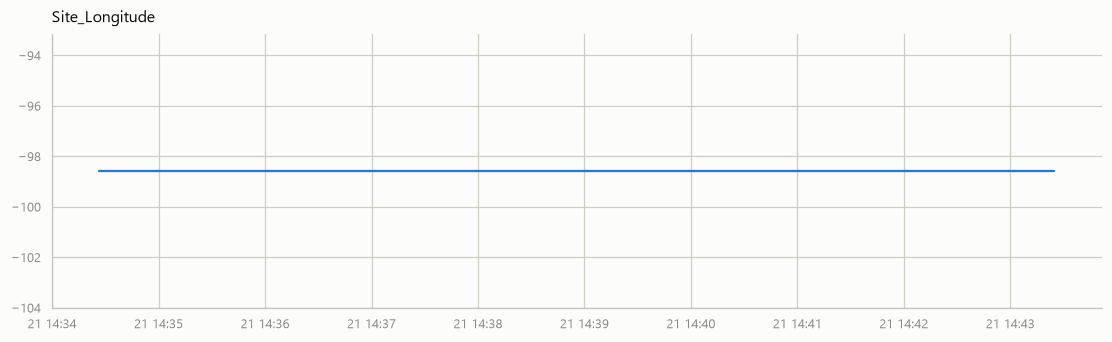

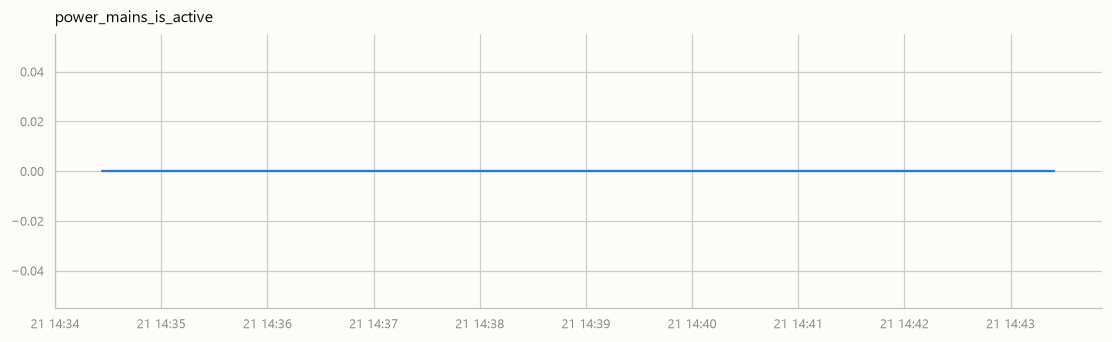

In [11]:
plot_signals(df, columns=cols)